# EDA Vehicle Insurance Claims

## Data Understanding

This is an vehicle insurance dataset "carclaims" that is publicly available in Kaggle through this [ link](https://www.kaggle.com/datasets/khusheekapoor/vehicle-insurance-fraud-detection/data). 

The dataset has 32 features in a total of which 6 are ordinal, 25 are categorical, and finally, the class variable that contains the label – “fraud” or “not-fraud”. It consists of 15,420 records of which only 6% (923 records) are fraudulent which indicates a high class imbalance.

In [1]:
import pandas as pd

df= pd.read_csv('data/raw/carclaims.csv')

In [2]:
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange-Claim,NumberOfCars,Year,BasePolicy,FraudFound
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability,No
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision,No
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision,No
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability,No
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision,No


In [3]:
print("shape: ", df.shape)
df.info()

shape:  (15420, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  PolicyNumber    

### Features review:

Listing out the columns and their unique values contained in each of them.

In [4]:
for column in df.columns:
    print(column + ':' + str(df[column].unique()))

Month:['Dec' 'Jan' 'Oct' 'Jun' 'Feb' 'Nov' 'Apr' 'Mar' 'Aug' 'Jul' 'May' 'Sep']
WeekOfMonth:[5 3 2 4 1]
DayOfWeek:['Wednesday' 'Friday' 'Saturday' 'Monday' 'Tuesday' 'Sunday' 'Thursday']
Make:['Honda' 'Toyota' 'Ford' 'Mazda' 'Chevrolet' 'Pontiac' 'Accura' 'Dodge'
 'Mercury' 'Jaguar' 'Nisson' 'VW' 'Saab' 'Saturn' 'Porche' 'BMW' 'Mecedes'
 'Ferrari' 'Lexus']
AccidentArea:['Urban' 'Rural']
DayOfWeekClaimed:['Tuesday' 'Monday' 'Thursday' 'Friday' 'Wednesday' 'Saturday' 'Sunday'
 '0']
MonthClaimed:['Jan' 'Nov' 'Jul' 'Feb' 'Mar' 'Dec' 'Apr' 'Aug' 'May' 'Jun' 'Sep' 'Oct'
 '0']
WeekOfMonthClaimed:[1 4 2 3 5]
Sex:['Female' 'Male']
MaritalStatus:['Single' 'Married' 'Widow' 'Divorced']
Age:[21 34 47 65 27 20 36  0 30 42 71 52 28 61 38 41 32 40 63 31 45 60 39 55
 35 44 72 29 37 59 49 50 26 48 64 33 74 23 25 56 16 68 18 51 22 53 46 43
 57 54 69 67 19 78 77 75 80 58 73 24 76 62 79 70 17 66]
Fault:['Policy Holder' 'Third Party']
PolicyType:['Sport - Liability' 'Sport - Collision' 'Sedan - Liability'


Summary from above:

- The columns `DayOfWeekClaimed`, `MonthClaimed` and `Age` contain 0 values, which are not valid in this context. These need further assessment to determine how to handle or clean these entries.

- For the columns `Days:Policy-Accident` and `Days:Policy-Claim`, a value of "none" is assumed to mean that the accident occurred on the same day the policy started.


## Data Quality Assessment and Cleaning

In [5]:
# check for missing values in each column
df.isnull().sum()

Month                   0
WeekOfMonth             0
DayOfWeek               0
Make                    0
AccidentArea            0
DayOfWeekClaimed        0
MonthClaimed            0
WeekOfMonthClaimed      0
Sex                     0
MaritalStatus           0
Age                     0
Fault                   0
PolicyType              0
VehicleCategory         0
VehiclePrice            0
PolicyNumber            0
RepNumber               0
Deductible              0
DriverRating            0
Days:Policy-Accident    0
Days:Policy-Claim       0
PastNumberOfClaims      0
AgeOfVehicle            0
AgeOfPolicyHolder       0
PoliceReportFiled       0
WitnessPresent          0
AgentType               0
NumberOfSuppliments     0
AddressChange-Claim     0
NumberOfCars            0
Year                    0
BasePolicy              0
FraudFound              0
dtype: int64

There are no missing values in any of the columns. However, as noted in the previous section, some columns contain 0 values instead of nulls, which may indicate missing or invalid data. Next, let's check if there are any duplicate records in the dataset.

In [6]:
df.duplicated().sum()

np.int64(0)

There are no duplicate rows in the dataset. Next, let's review the statistical summary of the numerical features.

In [7]:
# get summary statistic for numerical features

df.describe()

,WeekOfMonth,WeekOfMonthClaimed,Age,PolicyNumber,RepNumber,Deductible,DriverRating,Year
count,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,2.788586,2.693969,39.855707,7710.500000,8.483268,407.704280,2.487808,1994.866472
std,1.287585,1.259115,13.492377,4451.514911,4.599948,43.950998,1.119453,0.803313
min,1.000000,1.000000,0.000000,1.000000,1.000000,300.000000,1.000000,1994.000000
25%,2.000000,2.000000,31.000000,3855.750000,5.000000,400.000000,1.000000,1994.000000
50%,3.000000,3.000000,38.000000,7710.500000,8.000000,400.000000,2.000000,1995.000000
75%,4.000000,4.000000,48.000000,11565.250000,12.000000,400.000000,3.000000,1996.000000
max,5.000000,5.000000,80.000000,15420.000000,16.000000,700.000000,4.000000,1996.000000


All values appear to be valid except for the Age column, where the minimum value is 0. Next, we will examine the distribution of age values by reviewing the frequency of each unique value.

In [8]:
df.Age.value_counts().sort_index()

Age
0     320
16      9
17      6
18     48
19     32
     ... 
76     42
77     29
78     35
79     20
80     32
Name: count, Length: 66, dtype: int64

#### Cleaning Age column

In [9]:
print('Those with age=0 and their policy holder age count:\n{}'.format(df[df.Age == 0].AgeOfPolicyHolder.value_counts()))
df.AgeOfPolicyHolder.value_counts()

Those with age=0 and their policy holder age count:
AgeOfPolicyHolder
16 to 17    320
Name: count, dtype: int64


AgeOfPolicyHolder
31 to 35    5593
36 to 40    4043
41 to 50    2828
51 to 65    1392
26 to 30     613
over 65      508
16 to 17     320
21 to 25     108
18 to 20      15
Name: count, dtype: int64

In [10]:
df[df.Age == 0]['Fault'].value_counts()

Fault
Policy Holder    278
Third Party       42
Name: count, dtype: int64

Claims with age = 0 mostly come from policy holders who are in the youngest age group (16–17 years old). Therefore, when cleaning the data, we will replace age values of 0 with the minimum valid age for policy holders, which is 16.

In [11]:
# Define bins and labels
bins = [0,20,30,40,50,60,70,float('inf')]
labels = ['16 to 20', '21 to 30', '31 to 40', '41 to 50', '51 to 60', '61 to 70', 'over 70']

# Bin the age column
df['AgeGroup'] = pd.cut(df.Age, bins = bins, right=True, labels= labels, include_lowest=True)
df['AgeGroup'].fillna('16 to 20')

0        21 to 30
1        31 to 40
2        41 to 50
3        61 to 70
4        21 to 30
           ...   
15415    31 to 40
15416    21 to 30
15417    21 to 30
15418    31 to 40
15419    21 to 30
Name: AgeGroup, Length: 15420, dtype: category
Categories (7, object): ['16 to 20' < '21 to 30' < '31 to 40' < '41 to 50' < '51 to 60' < '61 to 70' < 'over 70']

We have created a new age group column. As discussed earlier, we will now replace any age value of 0 with 16. This is because an age of 0 actually corresponds to the minimum valid age group for policy holders (16 to 17 years old).

In [12]:
df.Age = df.Age.replace(0,16)

In [13]:
sum(df.Age == 0)

0

In [14]:
df.DayOfWeekClaimed.value_counts()

DayOfWeekClaimed
Monday       3757
Tuesday      3375
Wednesday    2951
Thursday     2660
Friday       2497
Saturday      127
Sunday         52
0               1
Name: count, dtype: int64

In [15]:
df[df.DayOfWeekClaimed == '0'] 

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange-Claim,NumberOfCars,Year,BasePolicy,FraudFound,AgeGroup
1516,Jul,2,Monday,Honda,Rural,0,0,1,Male,Single,...,No,No,External,none,no change,1 vehicle,1994,All Perils,No,16 to 20


Since this row contains a 0 value for both the `DayOfWeekClaimed` and `MonthClaimed` columns, it is safe to remove it from the dataset.

In [16]:
df = df[df.DayOfWeekClaimed != '0'] 

## Fraud Pattern Analysis

In [17]:
df.FraudFound.value_counts(normalize=True)

FraudFound
No     0.940139
Yes    0.059861
Name: proportion, dtype: float64

As clarified earlier, this is an inbalance dataset with ~6% target is fraud. Let us explore more on the fraud pattern base on the other features.

### Policy duration before incident

In [18]:
df['Days:Policy-Accident'].value_counts()

Days:Policy-Accident
more than 30    15246
none               55
8 to 15            55
15 to 30           49
1 to 7             14
Name: count, dtype: int64

In [19]:
table = df.groupby('FraudFound')['Days:Policy-Accident'].value_counts().unstack()
percent_table = table.apply(lambda x: x / x.sum(), axis=0)

table

Days:Policy-Accident,1 to 7,15 to 30,8 to 15,more than 30,none
FraudFound,,,,,
No,13,46,50,14341,46
Yes,1,3,5,905,9


In [20]:
percent_table

Days:Policy-Accident,1 to 7,15 to 30,8 to 15,more than 30,none
FraudFound,,,,,
No,0.928571,0.938776,0.909091,0.94064,0.836364
Yes,0.071429,0.061224,0.090909,0.05936,0.163636


Summary of Policy Duration Before Accident and Fraud Detection:

- Most claims occur after the policy has been active for more than 30 days (14,342 "No" and 905 "Yes" out of all claims).
- Fraud rate is highest when the accident occurs on the same day the policy starts (Days:Policy-Accident = none):
    - 16.4% of these claims are fraudulent, which is much higher than other groups.
- The second highest fraud rate is for accidents occurring 8 to 15 days after policy start (9.1% fraud).
- For claims made 1 to 7 days and 15 to 30 days after policy start, the fraud rates are lower (7.1% and 6.1% respectively).
- Lowest fraud rate is for claims made after the policy has been active for more than 30 days (5.9% fraud).

Key Points:
- Immediate claims ("none") are most suspicious: Policies with accidents reported on the same day as policy issuance have the highest fraud percentage.
- Early claims (within two weeks) also show elevated fraud rates compared to claims made after longer policy durations.
- Longer policy durations are associated with lower fraud rates.

This pattern suggests that claims made very soon after a policy is issued, especially on the same day, are more likely to be fraudulent and should be flagged for further investigation.

### Vehicle Characteristics

In [21]:
[cols for cols in df.columns if 'vehicle' in cols.lower()]


['VehicleCategory', 'VehiclePrice', 'AgeOfVehicle']

#### 1. Vehicle Age

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

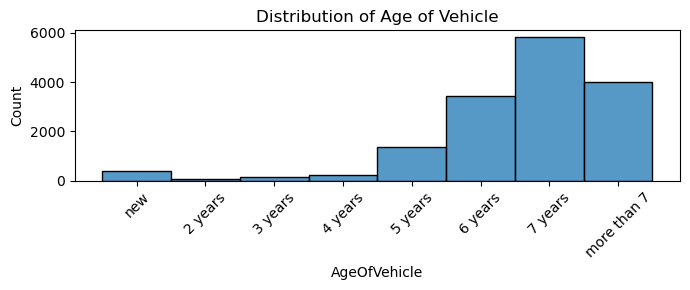

In [23]:
vehicle_age_order = [
    'new', '2 years', '3 years', '4 years', '5 years', '6 years', '7 years','more than 7'
]

# Set as categorical with order so when plotting it will follow order
df['AgeOfVehicle'] = pd.Categorical(df['AgeOfVehicle'], categories= vehicle_age_order, ordered=True)

fig, axes = plt.subplots(figsize=(7, 3))

sns.histplot(df['AgeOfVehicle'], ax=axes)
axes.set_title(f'Distribution of Age of Vehicle')
axes.tick_params(axis='x', rotation=45) # rotate x-axis label

plt.tight_layout()
plt.show()

In [24]:
table = df.groupby('FraudFound')['AgeOfVehicle'].value_counts().unstack()
percent_table = table.apply(lambda x: x / x.sum(), axis=0)
table

AgeOfVehicle,new,2 years,3 years,4 years,5 years,6 years,7 years,more than 7
FraudFound,,,,,,,,
No,340,70,139,208,1262,3220,5482,3775
Yes,32,3,13,21,95,228,325,206


In [25]:
percent_table

AgeOfVehicle,new,2 years,3 years,4 years,5 years,6 years,7 years,more than 7
FraudFound,,,,,,,,
No,0.913978,0.958904,0.914474,0.908297,0.929993,0.933875,0.944033,0.948254
Yes,0.086022,0.041096,0.085526,0.091703,0.070007,0.066125,0.055967,0.051746


Summary of Vehicle Age and Fraud Detection

- Highest fraud percentages are observed for vehicles aged 4 years (9.2%), followed by new vehicles (8.6%) and 3-year-old vehicles (8.6%).
- Most cars in the dataset are 6 years or older (i.e., the majority of claims are for vehicles aged 6 years, 7 years, or more than 7 years).
- Fraud rates are lower for older vehicles (6 years and above), with fraud percentages around 5–7%.
- This suggests that newer vehicles and those around 3–4 years old are more likely to be involved in fraudulent claims, while claims involving older vehicles are less likely to be fraudulent.


#### 2. Vehicle Category

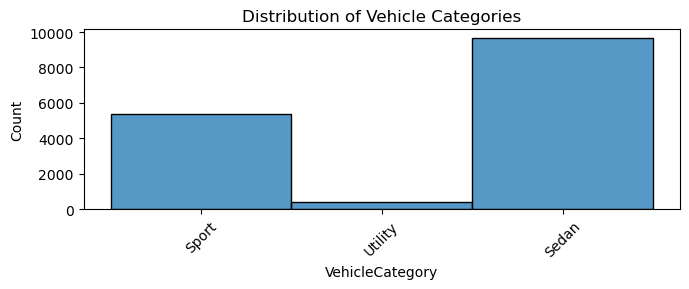

In [26]:

fig, axes = plt.subplots(figsize=(7, 3))

sns.histplot(df['VehicleCategory'], ax=axes)
axes.set_title(f'Distribution of Vehicle Categories')
axes.tick_params(axis='x', rotation=45) # rotate x-axis label

plt.tight_layout()
plt.show()

In [27]:
table = df.groupby('FraudFound')['VehicleCategory'].value_counts().unstack()
percent_table = table.apply(lambda x: x / x.sum(), axis=0)
table

VehicleCategory,Sedan,Sport,Utility
FraudFound,,,
No,8875,5274,347
Yes,795,84,44


In [28]:
percent_table

VehicleCategory,Sedan,Sport,Utility
FraudFound,,,
No,0.917787,0.984323,0.887468
Yes,0.082213,0.015677,0.112532


Summary of Vehicle Category and Fraud Detection

- Most claims are for Sedan and Sports cars, with Sedans having the highest number of claims, followed by Sports cars, and then Utility vehicles.
- Fraud rate for Sedans is much higher than for Sports and Utility vehicles. This means a larger proportion of fraudulent claims are associated with Sedans compared to the other categories.
- Utility vehicles have the lowest number of claims and also a lower fraud rate compared to Sedans.

#### 3. Vehicle Price

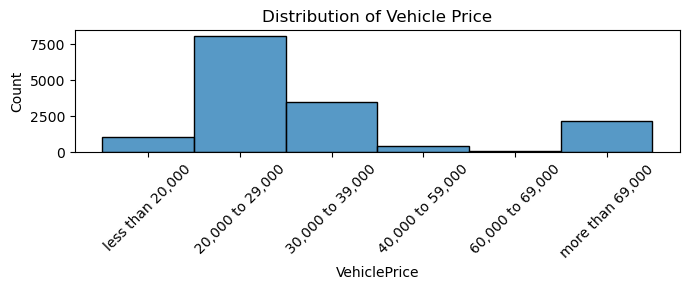

In [29]:
# set the vehicle price order
vehicle_price_order = [
    'less than 20,000', '20,000 to 29,000', '30,000 to 39,000',
    '40,000 to 59,000', '60,000 to 69,000', 'more than 69,000'
]

# Set as categorical with order so when plotting it will follow order
df['VehiclePrice'] = pd.Categorical(df['VehiclePrice'], categories= vehicle_price_order, ordered=True)

fig, axes = plt.subplots(figsize=(7, 3))

sns.histplot(df['VehiclePrice'], ax=axes)
axes.set_title(f'Distribution of Vehicle Price')
axes.tick_params(axis='x', rotation=45) # rotate x-axis label

plt.tight_layout()
plt.show()

In [30]:
table = df.groupby('FraudFound')['VehiclePrice'].value_counts().unstack()
percent_table = table.apply(lambda x: x / x.sum(), axis=0)
table

VehiclePrice,"less than 20,000","20,000 to 29,000","30,000 to 39,000","40,000 to 59,000","60,000 to 69,000","more than 69,000"
FraudFound,,,,,,
No,993,7658,3358,430,83,1974
Yes,103,421,175,31,4,189


In [31]:
percent_table

VehiclePrice,"less than 20,000","20,000 to 29,000","30,000 to 39,000","40,000 to 59,000","60,000 to 69,000","more than 69,000"
FraudFound,,,,,,
No,0.906022,0.94789,0.950467,0.932755,0.954023,0.912621
Yes,0.093978,0.05211,0.049533,0.067245,0.045977,0.087379


### Customer Demographics

#### 1. Accident Area

In [32]:
table = df.groupby('FraudFound')['AccidentArea'].value_counts().unstack()
table_proportion = df.groupby('FraudFound')['AccidentArea'].value_counts(normalize=True).unstack()
percent_table = table.apply(lambda x: x / x.sum(), axis=0)

pd.concat([table,table_proportion.add_suffix(' rate')])

AccidentArea,Rural,Urban,Rural rate,Urban rate
FraudFound,,,,
No,1464.0,13032.0,NaN,NaN
Yes,133.0,790.0,NaN,NaN
No,NaN,NaN,0.100993,0.899007
Yes,NaN,NaN,0.144095,0.855905


In [33]:
percent_table

AccidentArea,Rural,Urban
FraudFound,,
No,0.916719,0.942845
Yes,0.083281,0.057155


Summary of Vehicle Price and Fraud Detection

- Most claims are for vehicles priced between 20,000–29,000, followed by 30,000–39,000, and then more than 69,000.
- The highest fraud rates are observed for the cheapest vehicles (less than 20,000) at about 9.4%, followed by the most expensive vehicles (more than 69,000) at about 8.7%.
- Vehicles in the mid-price ranges (20,000–69,000) have noticeably lower fraud rates, with the lowest fraud rate in the 60,000–69,000 range (about 4.6%).

Additional Insights:

- This pattern suggests that both the lowest and highest vehicle price categories are more likely to be associated with fraudulent claims.
- The mid-range vehicles, which make up the bulk of claims, are less likely to be involved in fraud.
- Possible reasons could include opportunistic fraud for cheaper vehicles (easier to stage or less scrutiny) and higher incentives for fraud with expensive vehicles (larger payouts).

Summary of Accident Area and Fraud Rate:

- Nearly 90% of insurance claims occurred in urban areas, which is expected given higher population and vehicle density.
- However, the fraud rate is higher in rural areas compared to urban areas. This means that, although fewer claims originate from rural areas, a larger proportion of them are fraudulent relative to the total number of rural claims.

#### 2. Customer Gender

In [34]:
table = df.groupby('FraudFound')['Sex'].value_counts().unstack()
table_proportion = df.groupby('FraudFound')['Sex'].value_counts(normalize=True).unstack()
percent_table = table.apply(lambda x: x / x.sum(), axis=0)

pd.concat([table,table_proportion.add_suffix(' rate')])

Sex,Female,Male,Female rate,Male rate
FraudFound,,,,
No,2315.0,12181.0,NaN,NaN
Yes,105.0,818.0,NaN,NaN
No,NaN,NaN,0.159699,0.840301
Yes,NaN,NaN,0.113759,0.886241


In [35]:
percent_table

Sex,Female,Male
FraudFound,,
No,0.956612,0.937072
Yes,0.043388,0.062928


Summary of Customer Gender and Fraud Rate:

- Male customers are more likely to report insurance claims than female customers.
- The fraud rate is also higher among male claimants compared to female claimants. This means a larger proportion of claims from males are found to be fraudulent.

#### 3. Customer Age

In [36]:
table = df.groupby('FraudFound')['AgeGroup'].value_counts().unstack()
table_proportion = df.groupby('FraudFound')['AgeGroup'].value_counts(normalize=True).unstack()
percent_table = table.apply(lambda x: x / x.sum(), axis=0)

pd.concat([table,table_proportion])

AgeGroup,16 to 20,21 to 30,31 to 40,41 to 50,51 to 60,61 to 70,over 70
FraudFound,,,,,,,
No,393.000000,3193.000000,4511.000000,3289.000000,1994.000000,788.000000,328.000000
Yes,49.000000,203.000000,317.000000,186.000000,102.000000,50.000000,16.000000
No,0.027111,0.220268,0.311189,0.226890,0.137555,0.054360,0.022627
Yes,0.053088,0.219935,0.343445,0.201517,0.110509,0.054171,0.017335


In [37]:
percent_table

AgeGroup,16 to 20,21 to 30,31 to 40,41 to 50,51 to 60,61 to 70,over 70
FraudFound,,,,,,,
No,0.88914,0.940224,0.934341,0.946475,0.951336,0.940334,0.953488
Yes,0.11086,0.059776,0.065659,0.053525,0.048664,0.059666,0.046512


Summary of Customer Age and Fraud Rate:

- Most insurance claims are made by customers aged 21 to 50.
- The majority of fraud cases also occur in this age range, with the 31 to 40 group having the highest number of both claims and frauds.
- However, the fraud rate is highest in the 16 to 20 age group—about 11% of claims in this group are fraudulent, while other age groups have a fraud rate of only around 4–6%.

Additional Insights:

- Potential reasons for higher fraud rates in the 16–20 age group, such as inexperience, risk-taking behavior, or financial motivation.
- Recommendation: Consider targeted fraud detection strategies or additional verification for claims from the 16–20 age group.

#### 4. Marital Status

In [38]:
table = df.groupby('FraudFound')['MaritalStatus'].value_counts().unstack()
percent_table = table.apply(lambda x: x / x.sum(), axis=0)
table

MaritalStatus,Divorced,Married,Single,Widow
FraudFound,,,,
No,73,9986,4405,32
Yes,3,639,278,3


In [39]:
percent_table

MaritalStatus,Divorced,Married,Single,Widow
FraudFound,,,,
No,0.960526,0.939859,0.940636,0.914286
Yes,0.039474,0.060141,0.059364,0.085714


Summary of Marital Status and Fraud Rate:

- Most claims are made by customers who are married or single; these two groups also account for the majority of fraud cases.
- The widow group has the highest fraud rate among all marital statuses, but the number of claims in this group is very small, so its impact may be limited and should be interpreted with caution. The focus should remain on the married and single groups due to their larger sample sizes.

#### 5. Driver Rating

In [40]:
table = df.groupby('FraudFound')['DriverRating'].value_counts().unstack()
percent_table = table.apply(lambda x: x / x.sum(), axis=0)
table

DriverRating,1,2,3,4
FraudFound,,,,
No,3712,3586,3642,3556
Yes,232,214,242,235


In [41]:
percent_table

DriverRating,1,2,3,4
FraudFound,,,,
No,0.941176,0.943684,0.937693,0.938011
Yes,0.058824,0.056316,0.062307,0.061989


Summary of Driver Rating and Fraud Rate:

- The number of claims and the fraud rates are almost evenly distributed across all driver rating groups. There are no significant differences in fraud rates or claim counts between the different driver rating categories.
- This suggests that driver rating does not have a strong association with fraud occurrence in this dataset. It may not be a useful feature for distinguishing between fraudulent and non-fraudulent claims.

Additional Insight:
- Since there is no clear pattern or significant variation in fraud rates by driver rating, this feature might have limited predictive value for fraud detection. We may consider deprioritizing it in further analysis or feature selection for modeling.

### Incident Details
#### 1. Witness Present

In [42]:
table = df.groupby('FraudFound')['WitnessPresent'].value_counts().unstack()
table_proportion = df.groupby('FraudFound')['WitnessPresent'].value_counts(normalize=True).unstack()
percent_table = table.apply(lambda x: x / x.sum(), axis=0)

pd.concat([table,table_proportion])

WitnessPresent,No,Yes
FraudFound,,
No,14412.000000,84.000000
Yes,920.000000,3.000000
No,0.994205,0.005795
Yes,0.996750,0.003250


In [43]:
percent_table

WitnessPresent,No,Yes
FraudFound,,
No,0.939995,0.965517
Yes,0.060005,0.034483


Summary of Witness Present and Fraud Rate:

- The number of claims with a witness present is much lower compared to claims without a witness.
- The fraud rate for claims without a witness is almost double that of claims with a witness.
- However, due to the highly imbalanced sample size (very few claims with a witness), the difference in fraud rates may not be reliable or statistically meaningful.

Additional Input:

This imbalance suggests that "WitnessPresent" may not be a strong or stable predictor of fraud in this dataset. 

#### 2. Police Report Filed

In [44]:
table = df.groupby('FraudFound')['PoliceReportFiled'].value_counts().unstack()
table_proportion = df.groupby('FraudFound')['PoliceReportFiled'].value_counts(normalize=True).unstack()
percent_table = table.apply(lambda x: x / x.sum(), axis=0)

pd.concat([table,table_proportion])

PoliceReportFiled,No,Yes
FraudFound,,
No,14084.000000,412.000000
Yes,907.000000,16.000000
No,0.971578,0.028422
Yes,0.982665,0.017335


In [45]:
percent_table

PoliceReportFiled,No,Yes
FraudFound,,
No,0.939497,0.962617
Yes,0.060503,0.037383


Summary of Police Report Filed and Fraud Rate:

- The number of claims with a police report filed is much lower compared to claims without a police report.
- The fraud rate for claims without a police report is higher than for those with a police report filed.
- However, due to the highly imbalanced sample size (very few claims with a police report), the difference in fraud rates may not be reliable or statistically meaningful.

Additional Input:

This imbalance suggests that "PoliceReportFiled" may not be a strong or stable predictor of fraud in this dataset just like the Witness Present feature.

## Correlations and Statistical Significance

In this section, we evaluate the standalone predictive power of each feature with respect to the fraud target variable. For **numerical features**, we use the correlation coefficient to measure the strength and direction of association with the target and also the correlation between the column pairwise. For **categorical features**, we apply the chi-square test of independence (`chi2_contingency`) to assess whether there is a statistically significant association between each feature and fraud occurrence.

This approach allows us to identify which features are most strongly associated with fraud, either through linear correlation (for numerical variables) or through significant differences in fraud rates across categories (for categorical variables). Features with weak or non-significant associations may have limited value for predictive modeling.

### Correlation matrix:

Lets create our target column with 1 or 0 as output so that it will be numerical column. 

In [46]:
df['FraudFound'] = (df.FraudFound == 'Yes').astype(int)

In [47]:
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange-Claim,NumberOfCars,Year,BasePolicy,FraudFound,AgeGroup
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,No,No,External,none,1 year,3 to 4,1994,Liability,0,21 to 30
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,Yes,No,External,none,no change,1 vehicle,1994,Collision,0,31 to 40
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,No,No,External,none,no change,1 vehicle,1994,Collision,0,41 to 50
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability,0,61 to 70
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,No,No,External,none,no change,1 vehicle,1994,Collision,0,21 to 30


In [48]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,WeekOfMonth,WeekOfMonthClaimed,Age,PolicyNumber,RepNumber,Deductible,DriverRating,Year,FraudFound
WeekOfMonth,1.000000,0.275366,-0.007632,-0.007853,0.005340,-0.004000,-0.016834,-0.003949,-0.011872
WeekOfMonthClaimed,0.275366,1.000000,0.001418,0.011545,0.009033,0.005442,-0.000086,0.012082,-0.005783
Age,-0.007632,0.001418,1.000000,0.022449,-0.006374,0.069078,0.001275,0.022375,-0.027595
PolicyNumber,-0.007853,0.011545,0.022449,1.000000,0.009119,0.002117,-0.012352,0.936510,-0.020369
RepNumber,0.005340,0.009033,-0.006374,0.009119,1.000000,0.000525,0.011072,0.009438,-0.007529
Deductible,-0.004000,0.005442,0.069078,0.002117,0.000525,1.000000,0.003882,-0.001182,0.017345
DriverRating,-0.016834,-0.000086,0.001275,-0.012352,0.011072,0.003882,1.000000,-0.013922,0.007259
Year,-0.003949,0.012082,0.022375,0.936510,0.009438,-0.001182,-0.013922,1.000000,-0.024778
FraudFound,-0.011872,-0.005783,-0.027595,-0.020369,-0.007529,0.017345,0.007259,-0.024778,1.000000


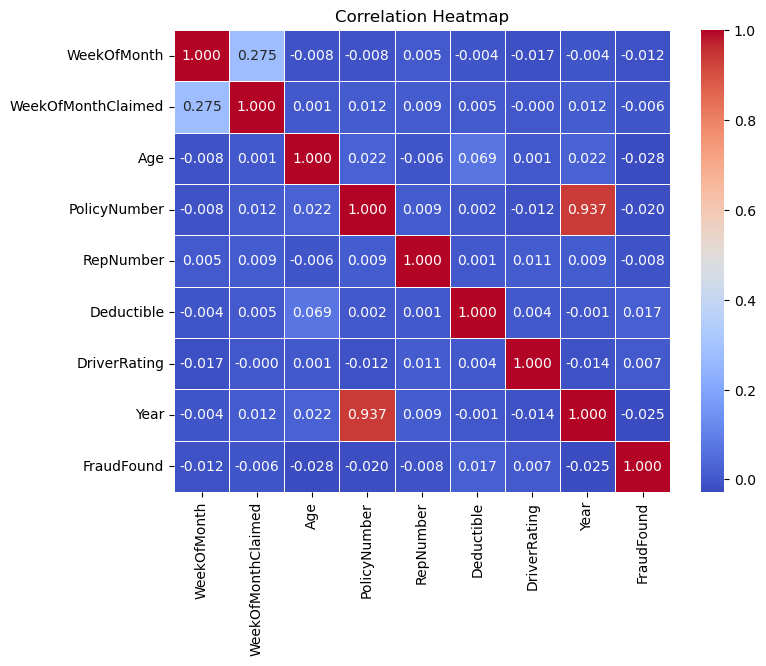

In [49]:
import seaborn as sns

plt.figure(figsize=(8, 6)) # Adjust figure size for better readability
sns.heatmap(corr_matrix, annot= True, cmap= 'coolwarm', fmt='.3f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()



High correlation between "Year" and "Policy Number": This is expected if policy numbers are assigned sequentially over time.

This may indicate redundancy, we might consider dropping one for modeling later.

In [50]:
df.corr(numeric_only=True)['FraudFound'].drop('FraudFound').sort_values()

Age                  -0.027595
Year                 -0.024778
PolicyNumber         -0.020369
WeekOfMonth          -0.011872
RepNumber            -0.007529
WeekOfMonthClaimed   -0.005783
DriverRating          0.007259
Deductible            0.017345
Name: FraudFound, dtype: float64

None of the columns seems to be correlated with the Fraud found column. 

### Statistical Significance & Chi-Square Test
correlation matrix covers the correlation on the numerical features only. Hence we are going to use Statistical significance to see if the differences in fraud rates across categories are significant. 

Our hypotheses are as below:
- **Null hypothesis**: There is no association between the feature (e.g., VehiclePrice) and fraud occurrence (FraudFound). Any differences in fraud rates across categories are due to random variation.
- **Alternative hypothesis**: There is an association — the feature and fraud are related.

Steps:

1. Create a contigency table of counts of each category vs. fraud status
2. Run the chi-square test using scipy.stats.chie_contigency
3. Interpret the p-value:
    - if p< 0.05 -> reject null hypothesis (differences in fraud rates are statistically significant)
    - if p> 0.05 -> cannot conclude there is a real association

In [52]:
import pandas as pd
from scipy.stats import chi2_contingency

# Find non-numerical columns (excluding the target)
non_num_cols = df.select_dtypes(exclude='number').columns
p_sig = {}      # Significant: p < 0.05
p_non_sig = {}  # Not Significant: p > 0.05

# Calculate the chi-square p-value for each non-numerical column vs FraudFound
for col in non_num_cols:

    contingency = pd.crosstab(df[col], df['FraudFound'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    if p < 0.05:
        p_sig[col] = p
    else:
        p_non_sig[col] = p
    # print(f"{col}: p-value = {p}")
    
# order the significant columns from most signifant(smallest p value) to least
sorted_sig = sorted(p_sig.items(), key=lambda x:x[1])
print(f"\nSignificant columns (p < 0.05): \n")
for col, p in sorted_sig:
    print(f"{col} : {p}")

# order the non significant columns from most non signifant(biggest p value) to least
sorted_non_sig = sorted(p_non_sig.items(), key=lambda x:x[1], reverse= True)
print(f"\nNot Significant columns (p < 0.05): \n")
for col, p in sorted_non_sig:
    print(f"{col} : {p}")


Significant columns (p < 0.05): 

PolicyType : 1.7684408625067324e-89
BasePolicy : 3.170435582804212e-88
VehicleCategory : 6.520816983936526e-64
Fault : 1.4061798322083448e-59
AddressChange-Claim : 9.704718134488268e-22
VehiclePrice : 2.8883241258916084e-13
PastNumberOfClaims : 1.4051975984632896e-11
Make : 2.191573083758744e-06
MonthClaimed : 1.4952445828227434e-05
AgeGroup : 1.991004079684891e-05
AccidentArea : 3.9363035441822324e-05
AgeOfPolicyHolder : 5.89656043573437e-05
Sex : 0.00023911350965670762
NumberOfSuppliments : 0.00040852764695793487
Month : 0.0017209020924110242
AgeOfVehicle : 0.0025453223015676246
AgentType : 0.006593596931650737
Days:Policy-Accident : 0.02085381331813133

Not Significant columns (p < 0.05): 

MaritalStatus : 0.7982546576174133
NumberOfCars : 0.6599325542881813
DayOfWeekClaimed : 0.5316063163312554
WitnessPresent : 0.4389010193312336
DayOfWeek : 0.11836116248221318
Days:Policy-Claim : 0.08994050543498808
PoliceReportFiled : 0.05946843701670173


Most of the categorical columns show significant association with fraud (p < 0.05) except for four columns:
- `WitnessPresent`
- `DayOfWeek`
- `Days:Policy-Claim`
- `PoliceReportFiled`

Key implications:
1. **Significant Features**: The majority of categorical variables have statistically significant relationships with fraud occurrence, making them potentially valuable predictors for fraud detection modeling.

2. **Non-Significant Features**:
   - Both `WitnessPresent` and `PoliceReportFiled` show non-significance, which aligns with our earlier observation about their highly imbalanced distributions
   - `DayOfWeek` suggests that fraud doesn't follow a specific weekly pattern
   - `Days:Policy-Claim` timing appears less important than the accident-to-policy duration

This analysis helps prioritize features for modeling:
- Focus on the statistically significant features for initial model development
- Consider excluding or giving less weight to non-significant features
- Validate these findings during feature selection phase of modeling

## Conclusion

### Key Findings

1. **Timing Patterns**
   - Highest fraud rate (16.4%) in claims filed same day as policy start
   - Fraud risk decreases with policy duration

2. **Vehicle Factors**
   - Higher fraud rates in newer vehicles (3-4 years old)
   - Sedans show higher fraud rates than other vehicle types
   - Both lowest and highest price vehicles show elevated fraud risk

3. **Demographics**
   - Young drivers (16-20) have highest fraud rate (~11%)
   - Male customers show higher fraud rates
   - Rural areas have proportionally more fraud cases

4. **Statistical Significance**
   - Most categorical features show significant association with fraud
   - No strong linear correlations found with numerical features
   - Year and Policy Number are highly correlated and redundant

---

### Next Steps

1. Apply value encoding to categorical features for modeling.
2. Remove either the Year or Policy Number column to address redundancy due to strong correlation.
3. Consider excluding or giving less weight to non-significant features



Save the processed data in interim folder.

In [53]:
df.to_csv('data/interim/claims_cleaned.csv',index=False)